In [4]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import CubicSpline, PchipInterpolator, lagrange
from numpy.polynomial.polynomial import Polynomial

with np.load('data_interp.npz') as data:
    x1, y1 = data['x1'], data['y1']

x = np.linspace(min(x1), max(x1), 1000)

coeffs_lagrange = np.polyfit(x1, y1, len(x1)-1)
y_lagrange = np.polyval(coeffs_lagrange, x)

cs = CubicSpline(x1, y1)
y_spline = cs(x)

pchip = PchipInterpolator(x1, y1)
y_pchip = pchip(x)

degrees = [3, 5, 7]
poly_fits = {}

for degree in degrees:
    coeffs = np.polyfit(x1, y1, degree)
    poly_fits[degree] = np.polyval(coeffs, x)

C:\Users\user\AppData\Local\Temp\ipykernel_39568\1322606719.py:11: RankWarning: Polyfit may be poorly conditioned
  coeffs_lagrange = np.polyfit(x1, y1, len(x1)-1)


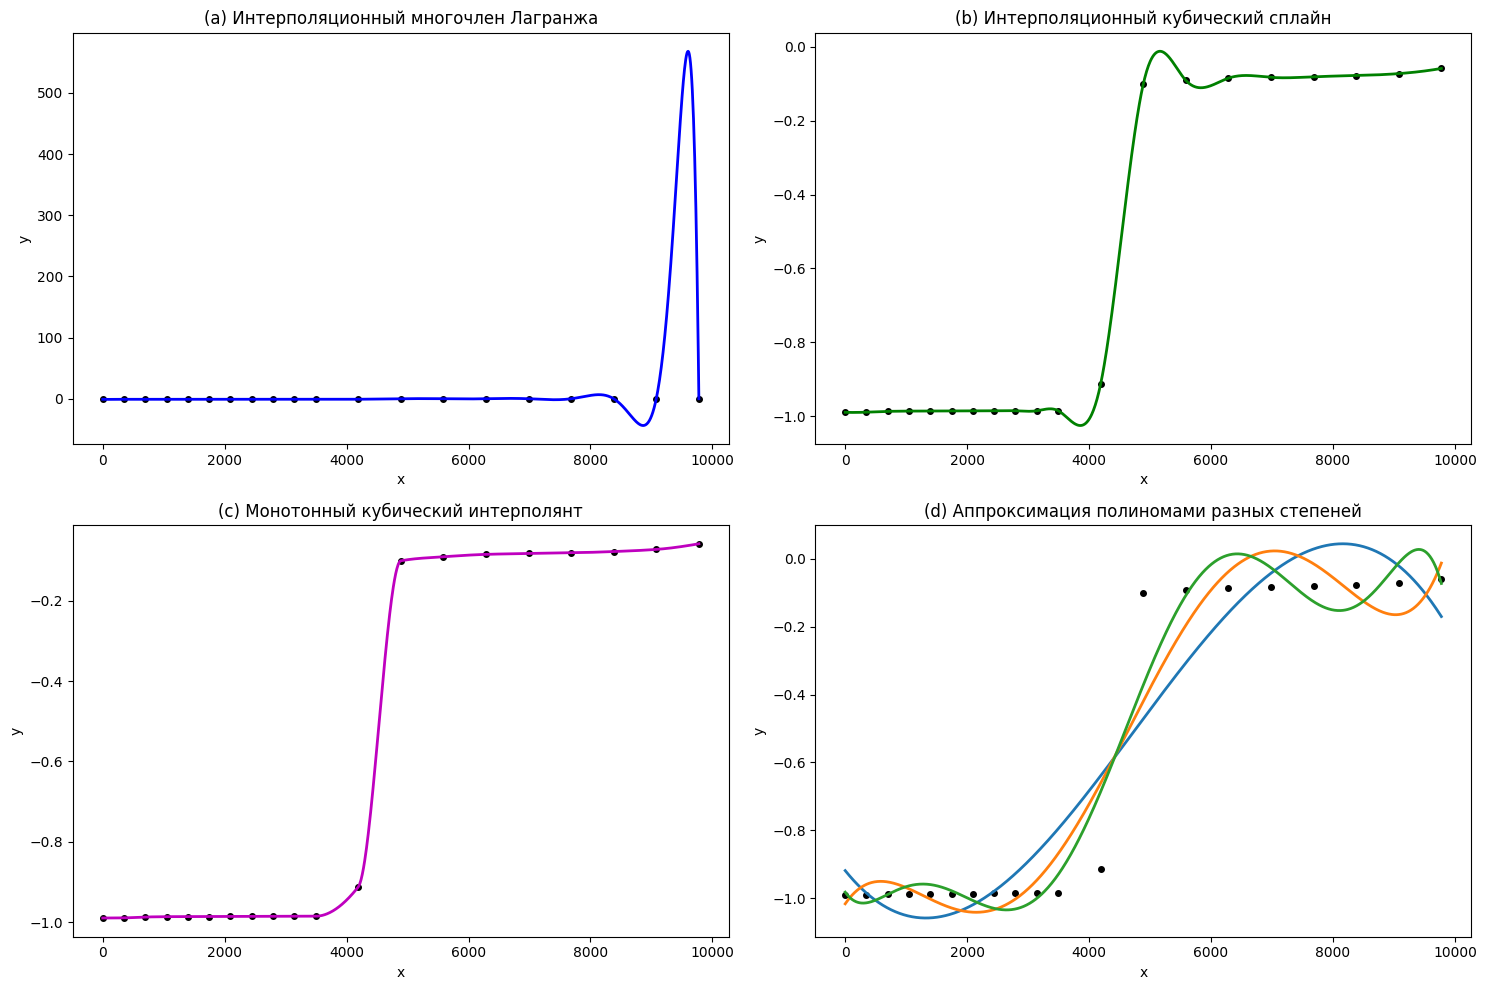

In [11]:
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

ax1 = axes[0, 0]
ax1.plot(x1, y1, 'ko', markersize=4, label='Исходные данные')
ax1.plot(x, y_lagrange, 'b-', linewidth=2, label='Интерполяция Лагранжа')
ax1.set_title('(a) Интерполяционный многочлен Лагранжа')
ax1.set_xlabel('x')
ax1.set_ylabel('y')

ax2 = axes[0, 1]
ax2.plot(x1, y1, 'ko', markersize=4, label='Исходные данные')
ax2.plot(x, y_spline, 'g-', linewidth=2, label='Кубический сплайн')
ax2.set_title('(b) Интерполяционный кубический сплайн')
ax2.set_xlabel('x')
ax2.set_ylabel('y')

ax3 = axes[1, 0]
ax3.plot(x1, y1, 'ko', markersize=4, label='Исходные данные')
ax3.plot(x, y_pchip, 'm-', linewidth=2, label='Pchip (монотонный)')
ax3.set_title('(c) Монотонный кубический интерполянт')
ax3.set_xlabel('x')
ax3.set_ylabel('y')

ax4 = axes[1, 1]
ax4.plot(x1, y1, 'ko', markersize=4, label='Исходные данные')
for degree, y_fit in zip(degrees, [poly_fits[d] for d in degrees]):
    ax4.plot(x, y_fit, linewidth=2, 
             label=f'Полином степени {degree}')
ax4.set_title('(d) Аппроксимация полиномами разных степеней')
ax4.set_xlabel('x')
ax4.set_ylabel('y')

plt.tight_layout()
plt.show()

In [14]:
import numpy as np

class LagrangeInterpolator:
    """Lagrange interpolating polynomial.

    Given a set of pairs ``(x_k, y_k)``, construct
    a Lagrange polynomial ``f(x)``, such that

    .. math::

        f(x_k) = y_k   for k =0, ..., n-1

    Parameters
    ----------
    xk : array_like, shape(n,)
        Abscissas
    yk : array_like, shape(n,)
        Ordinates

    Attributes
    ----------
    __call__

    """
    def __init__(self, xk, yk):
        self.xk = np.asarray(xk, dtype=float)
        self.yk = np.asarray(yk, dtype=float)
        
        n = len(self.xk)
        self.denominators = np.zeros(n)
        for i in range(n):
            self.denominators[i] = np.prod([self.xk[i] - self.xk[j] 
                                            for j in range(n) if j != i])

    def __call__(self, x):
        """Evaluate the interpolator at a given point.

        Parameters
        ----------
        x : float

        Returns
        -------
        the value of the interpolator at ``x``.
        """

        if isinstance(x, (list, np.ndarray)):
            return np.array([self._evaluate_single(xi) for xi in x])
        else:
            return self._evaluate_single(x)
    
    def _evaluate_single(self, x):
        """Evaluate the interpolator at a single point."""
        n = len(self.xk)
        
        for i in range(n):
            if np.abs(x - self.xk[i]) < 1e-14:
                return self.yk[i]

        result = 0.0
        for i in range(n):
            numerator = np.prod([x - self.xk[j] for j in range(n) if j != i])
            result += self.yk[i] * numerator / self.denominators[i]
        
        return result

def runge_func(x, a=25):
    return 1.0 / (1.0 + a*x**2)

xx = np.linspace(-2, 2, 21)
yy = runge_func(xx)

lagr = LagrangeInterpolator(xx, yy)

from numpy.testing import assert_allclose

assert_allclose(yy,
                [lagr(xval) for xval in xx],
                atol=1e-14)

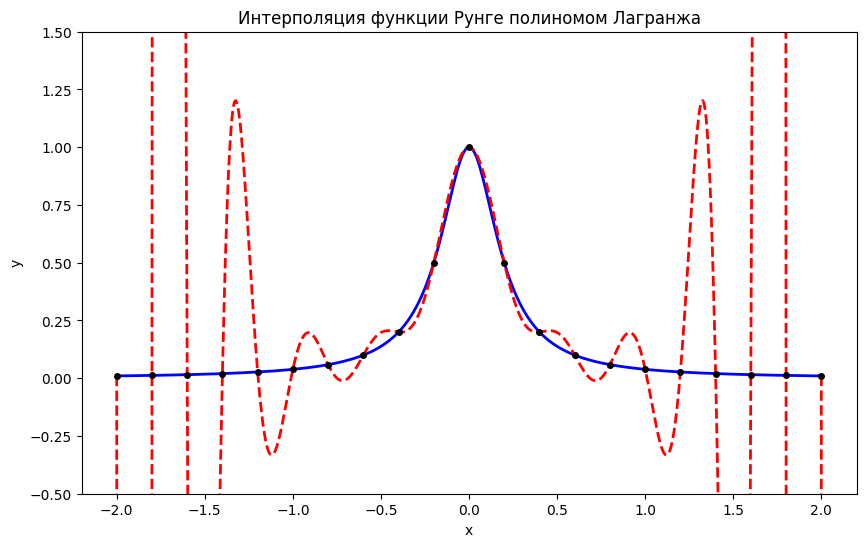

In [16]:
x_dense = np.linspace(-2, 2, 1000)
y_exact = runge_func(x_dense)
y_interp = lagr(x_dense)

plt.figure(figsize=(10, 6))
plt.plot(x_dense, y_exact, 'b-', linewidth=2, label='Точная функция Рунге')
plt.plot(x_dense, y_interp, 'r--', linewidth=2, label='Интерполяция Лагранжа')
plt.plot(xx, yy, 'ko', markersize=4, label='Узлы интерполяции')
plt.xlabel('x')
plt.ylabel('y')
plt.title('Интерполяция функции Рунге полиномом Лагранжа')
plt.ylim(-0.5, 1.5)
plt.show()

In [17]:
def cheb_nodes(n, a=-1, b=1):

    k = np.arange(1, n+1)
    nodes_cheb = np.cos((2*k - 1) * np.pi / (2*n))
    
    nodes_scaled = (b - a)/2 * nodes_cheb + (a + b)/2
    
    nodes_scaled = np.sort(nodes_scaled)
    
    return nodes_scaled

n = 11
x_uniform = np.linspace(-2, 2, n) 
y_uniform = runge_func(x_uniform)

x_cheb = cheb_nodes(n, -2, 2)
y_cheb = runge_func(x_cheb)

lagrange_uniform = LagrangeInterpolator(x_uniform, y_uniform)
lagrange_cheb = LagrangeInterpolator(x_cheb, y_cheb)

spline_uniform = CubicSpline(x_uniform, y_uniform)
spline_cheb = CubicSpline(x_cheb, y_cheb)

x_dense = np.linspace(-2, 2, 1000)
y_exact = runge_func(x_dense)

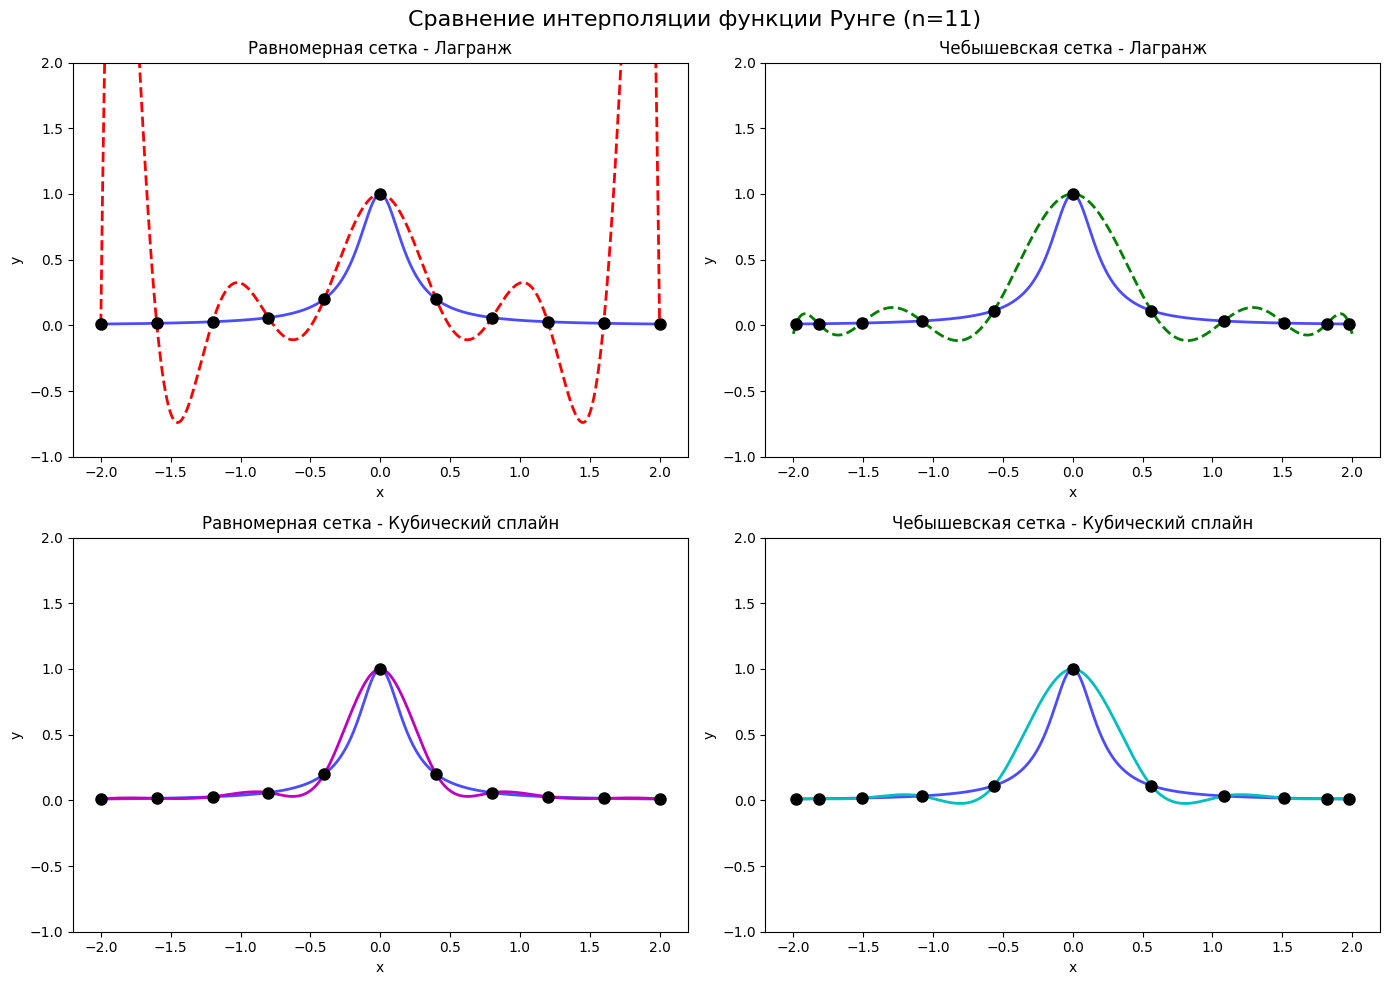

In [21]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Сравнение интерполяции функции Рунге (n=11)', fontsize=16)

ax1 = axes[0, 0]
ax1.plot(x_dense, y_exact, 'b-', linewidth=2, label='Точная функция', alpha=0.7)
ax1.plot(x_dense, lagrange_uniform(x_dense), 'r--', linewidth=2, label='Интерполяция Лагранжа')
ax1.plot(x_uniform, y_uniform, 'ko', markersize=8, label='Узлы интерполяции')
ax1.set_title('Равномерная сетка - Лагранж')
ax1.set_xlabel('x')
ax1.set_ylabel('y')
ax1.set_ylim(-1, 2)

ax2 = axes[0, 1]
ax2.plot(x_dense, y_exact, 'b-', linewidth=2, label='Точная функция', alpha=0.7)
ax2.plot(x_dense, lagrange_cheb(x_dense), 'g--', linewidth=2, label='Интерполяция Лагранжа')
ax2.plot(x_cheb, y_cheb, 'ko', markersize=8, label='Узлы Чебышева')
ax2.set_title('Чебышевская сетка - Лагранж')
ax2.set_xlabel('x')
ax2.set_ylabel('y')
ax2.set_ylim(-1, 2)

ax3 = axes[1, 0]
ax3.plot(x_dense, y_exact, 'b-', linewidth=2, label='Точная функция', alpha=0.7)
ax3.plot(x_dense, spline_uniform(x_dense), 'm-', linewidth=2, label='Кубический сплайн')
ax3.plot(x_uniform, y_uniform, 'ko', markersize=8, label='Узлы интерполяции')
ax3.set_title('Равномерная сетка - Кубический сплайн')
ax3.set_xlabel('x')
ax3.set_ylabel('y')
ax3.set_ylim(-1, 2)

ax4 = axes[1, 1]
ax4.plot(x_dense, y_exact, 'b-', linewidth=2, label='Точная функция', alpha=0.7)
ax4.plot(x_dense, spline_cheb(x_dense), 'c-', linewidth=2, label='Кубический сплайн')
ax4.plot(x_cheb, y_cheb, 'ko', markersize=8, label='Узлы Чебышева')
ax4.set_title('Чебышевская сетка - Кубический сплайн')
ax4.set_xlabel('x')
ax4.set_ylabel('y')
ax4.set_ylim(-1, 2)

plt.tight_layout()
plt.show()

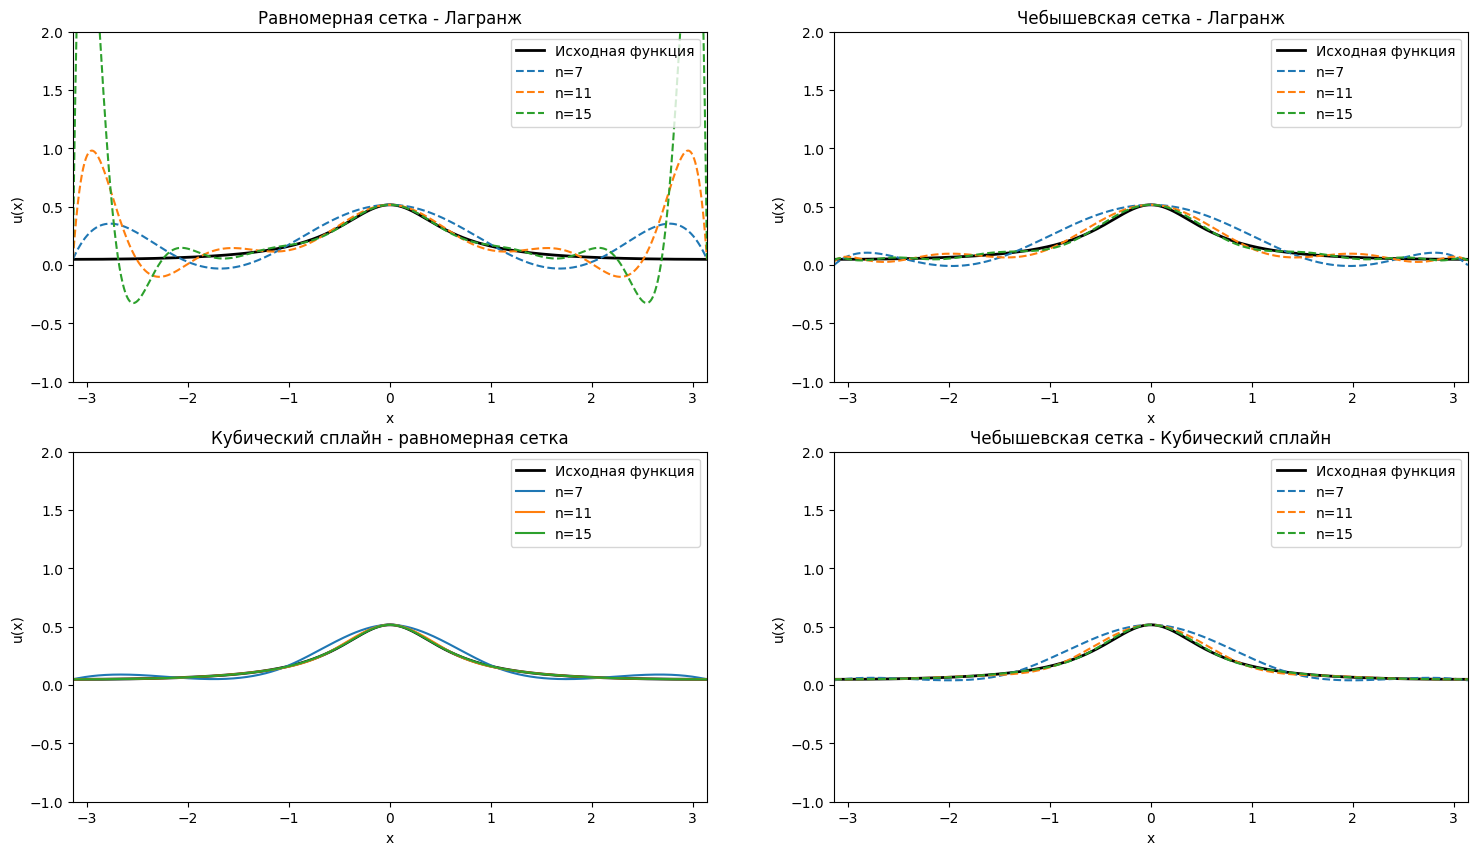

In [35]:
def u(x, eps=0.21):

    return np.sqrt(eps * (2 + eps)) / (2 * np.pi * (1 + eps - np.cos(x)))

a, b = -np.pi, np.pi  

x_dense = np.linspace(a, b, 2000)
y_exact = u(x_dense)

n_values = [7, 11, 15]

fig, axes = plt.subplots(2, 2, figsize=(18, 10))

ax2 = axes[0, 0]
ax2.plot(x_dense, y_exact, 'k-', linewidth=2, label='Исходная функция')
for n in n_values:
    x_uniform = np.linspace(a, b, n)
    y_uniform = u(x_uniform)
    lagrange = LagrangeInterpolator(x_uniform, y_uniform)
    ax2.plot(x_dense, lagrange(x_dense), '--', 
             linewidth=1.5, label=f'n={n}')
ax2.set_title('Равномерная сетка - Лагранж')
ax2.set_xlabel('x')
ax2.set_ylabel('u(x)')
ax2.legend(loc='upper right')
ax2.set_xlim(a, b)
ax2.set_ylim(-1, 2)

ax3 = axes[0, 1]
ax3.plot(x_dense, y_exact, 'k-', linewidth=2, label='Исходная функция')
for n in n_values:
    x_cheb = cheb_nodes(n, a, b)
    y_cheb = u(x_cheb)
    lagrange = LagrangeInterpolator(x_cheb, y_cheb)
    ax3.plot(x_dense, lagrange(x_dense), '--', 
             linewidth=1.5, label=f'n={n}')
ax3.set_title('Чебышевская сетка - Лагранж')
ax3.set_xlabel('x')
ax3.set_ylabel('u(x)')
ax3.legend(loc='upper right')
ax3.set_xlim(a, b)
ax3.set_ylim(-1, 2)

ax4 = axes[1, 0]
ax4.plot(x_dense, y_exact, 'k-', linewidth=2, label='Исходная функция')
for n in n_values:
    x_uniform = np.linspace(a, b, n)
    y_uniform = u(x_uniform)
    spline = CubicSpline(x_uniform, y_uniform)
    ax4.plot(x_dense, spline(x_dense), '-', 
             linewidth=1.5, label=f'n={n}')
ax4.set_title('Кубический сплайн - равномерная сетка')
ax4.set_xlabel('x')
ax4.set_ylabel('u(x)')
ax4.legend(loc='upper right')
ax4.set_xlim(a, b)
ax4.set_ylim(-1, 2)

ax5 = axes[1, 1]
ax5.plot(x_dense, y_exact, 'k-', linewidth=2, label='Исходная функция')
for n in n_values:
    x_cheb = cheb_nodes(n, a, b)
    y_cheb = u(x_cheb)
    spline = CubicSpline(x_cheb, y_cheb)
    ax5.plot(x_dense, spline(x_dense), '--', 
             linewidth=1.5, label=f'n={n}')
ax5.set_title('Чебышевская сетка - Кубический сплайн')
ax5.set_xlabel('x')
ax5.set_ylabel('u(x)')
ax5.legend(loc='upper right')
ax5.set_xlim(a, b)
ax5.set_ylim(-1, 2)


plt.show()

In [2]:
import numpy as np

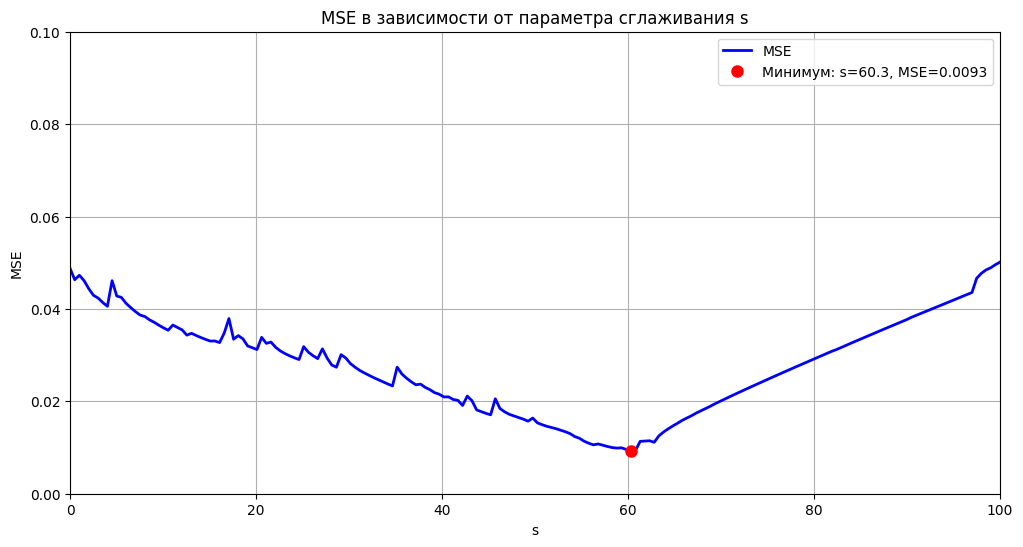

In [7]:
from scipy.interpolate import UnivariateSpline

np.random.seed(42)
n_points = 80
x = np.linspace(0, 10, n_points)
sigma_noise = 0.25

y_true = 5 * np.sin(x)
y_noisy = y_true + sigma_noise * np.random.randn(n_points)

weights = np.ones(n_points) / sigma_noise

x_dense = np.linspace(0, 10, 1000)
y_dense_true = 5 * np.sin(x_dense)

s_values = np.linspace(0, 100, 200)
mse_values = []

for s in s_values:
    spline = UnivariateSpline(x, y_noisy, w=weights, s=s)
    y_spline = spline(x_dense)
    mse = np.mean((y_dense_true - y_spline)**2)
    mse_values.append(mse)

m = n_points
s_low = m - np.sqrt(2*m)
s_high = m + np.sqrt(2*m)
s_lenw = len(weights)

plt.figure(figsize=(12, 6))
plt.plot(s_values, mse_values, 'b-', linewidth=2, label='MSE')

# plt.axvspan(s_low, s_high, alpha=0.2, color='green', 
#             label=f'Рекомендуемый диапазон: ({s_low:.1f}, {s_high:.1f})')

# plt.axvline(x=s_lenw, color='r', linestyle='--', 
#             label=f's = len(w) = {s_lenw}', linewidth=2)

min_idx = np.argmin(mse_values)
min_s = s_values[min_idx]
min_mse = mse_values[min_idx]
plt.plot(min_s, min_mse, 'ro', markersize=8, 
         label=f'Минимум: s={min_s:.1f}, MSE={min_mse:.4f}')

plt.xlabel('s')
plt.ylabel('MSE')
plt.title('MSE в зависимости от параметра сглаживания s')
plt.legend()
plt.grid()
plt.xlim(0, 100)
plt.ylim(0, 0.1)
plt.show()


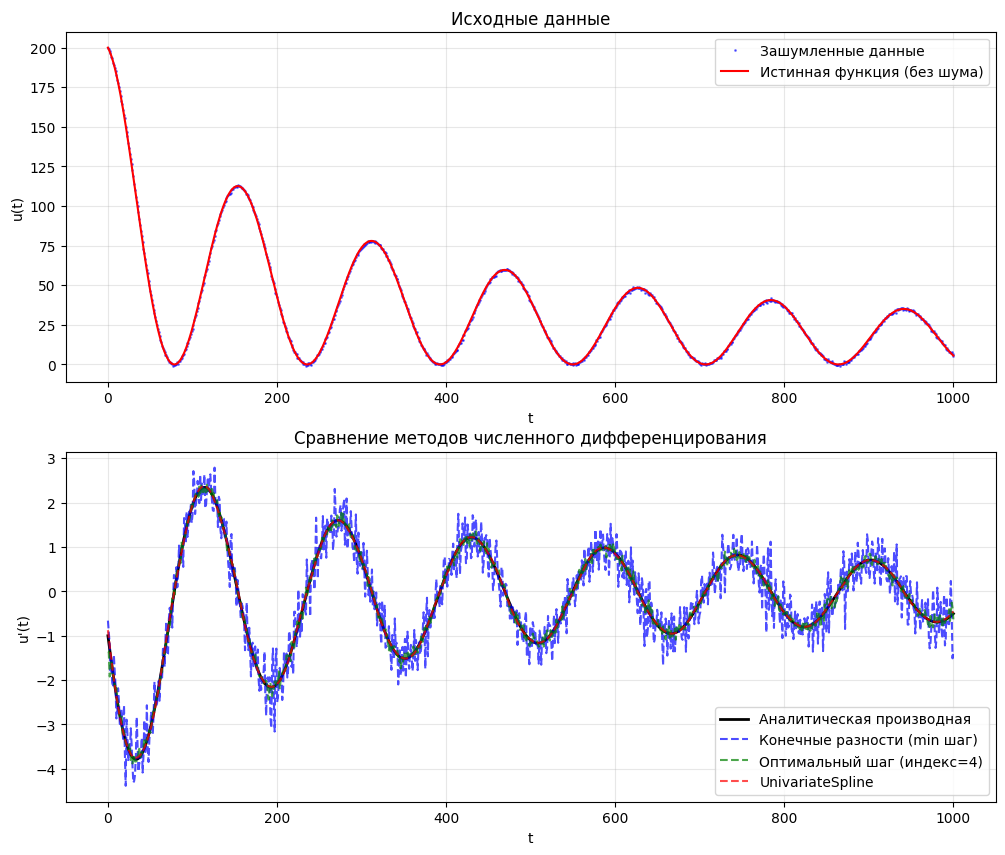

In [ ]:
t = np.linspace(0, 1000, 1000)
u = 200 / (1 + t/200) * (0.5 + 0.5 * np.cos(0.04 * t)) + 0.5 * np.random.randn(len(t))

def analytical_derivative(t):

    term1 = 200/(1 + t/200)
    term2 = 0.5 + 0.5 * np.cos(0.04 * t)
    d_term1 = -200 * (1/200) / (1 + t/200)**2 
    d_term2 = -0.5 * 0.04 * np.sin(0.04 * t)
    
    return d_term1 * term2 + term1 * d_term2

u_true = analytical_derivative(t)
h_min = t[1] - t[0] 
derivative_fd = np.gradient(u, h_min)

def estimate_noise_level(u):
    noise_estimate = np.std(np.diff(u)) / np.sqrt(2)
    return noise_estimate

def estimate_second_derivative(t, u):
    from scipy.ndimage import gaussian_filter1d
    u_smooth = gaussian_filter1d(u, sigma=5)
    d2 = np.gradient(np.gradient(u_smooth, t[1]-t[0]), t[1]-t[0])
    return np.mean(np.abs(d2))

noise_level = estimate_noise_level(u)
second_deriv = estimate_second_derivative(t, u)

h_opt_index = int((3 * noise_level / (second_deriv + 1e-10))**(1/3) / h_min)

def derivative_optimal_step(t, u, step_index):
    derivative = np.zeros_like(u)
    for i in range(step_index, len(u)-step_index):
        derivative[i] = (u[i+step_index] - u[i-step_index]) / (t[i+step_index] - t[i-step_index])
    
    for i in range(step_index):
        derivative[i] = (u[i+step_index] - u[i]) / (t[i+step_index] - t[i])
    
    for i in range(len(u)-step_index, len(u)):
        derivative[i] = (u[i] - u[i-step_index]) / (t[i] - t[i-step_index])
    
    return derivative

derivative_opt = derivative_optimal_step(t, u, h_opt_index)


s = len(t)
spline = UnivariateSpline(t, u, w=np.ones_like(t) * 2, s=s)
spline_derivative = spline.derivative()
derivative_spline = spline_derivative(t)

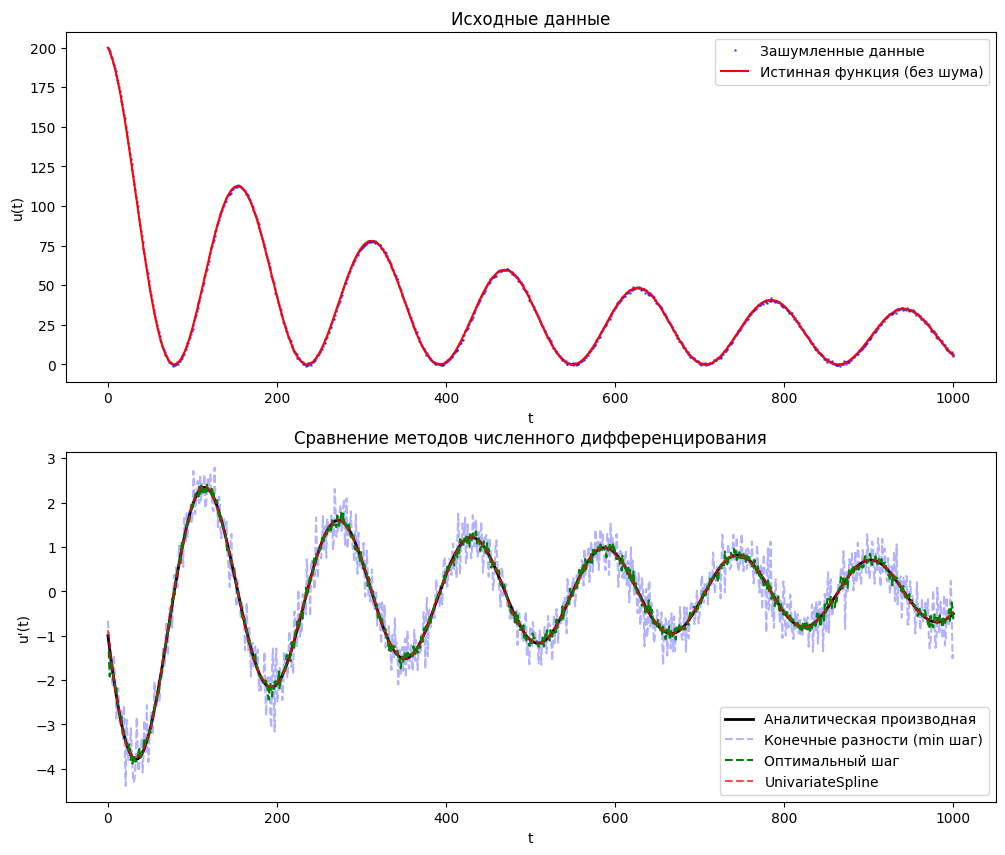

Конечные разности (min шаг):
  MAE = 0.2780
  RMSE = 0.3459
Оптимальный шаг:
  MAE = 0.0731
  RMSE = 0.0937
UnivariateSpline:
  MAE = 0.0145
  RMSE = 0.0190


In [76]:
fig, axes = plt.subplots(2, 1, figsize=(12, 10))

axes[0].plot(t, u, 'b.', markersize=2, alpha=0.5, label='Зашумленные данные')
axes[0].plot(t, 200/(1+t/200)*(0.5+0.5*np.cos(0.04*t)), 'r-', label='Истинная функция (без шума)')
axes[0].set_xlabel('t')
axes[0].set_ylabel('u(t)')
axes[0].set_title('Исходные данные')
axes[0].legend()

axes[1].plot(t, u_true, 'k-', linewidth=2, label='Аналитическая производная')
axes[1].plot(t, derivative_fd, 'b--', alpha=0.3, label=f'Конечные разности (min шаг)')
axes[1].plot(t, derivative_opt, 'g--', label=f'Оптимальный шаг')
axes[1].plot(t, derivative_spline, 'r--', alpha=0.7, label='UnivariateSpline')
axes[1].set_xlabel('t')
axes[1].set_ylabel("u'(t)")
axes[1].set_title('Сравнение методов численного дифференцирования')
axes[1].legend()
plt.show()

def compute_errors(true, estimated, name):
    mae = np.mean(np.abs(true - estimated))
    rmse = np.sqrt(np.mean((true - estimated)**2))
    print(f"{name}:")
    print(f"  MAE = {mae:.4f}")
    print(f"  RMSE = {rmse:.4f}")
    return mae, rmse

errors_fd = compute_errors(u_true, derivative_fd, "Конечные разности (min шаг)")
errors_opt = compute_errors(u_true, derivative_opt, "Оптимальный шаг")
errors_spline = compute_errors(u_true, derivative_spline, "UnivariateSpline")